<table width="100%">
  <tr>
    <td align="left" valign="middle" width="100%">
      <img src="../docs/assets/logo_bristol.png" alt="University of Bristol" width="200" />
    </td>
    <td align="right" valign="middle" width="100%">
      <img src="../docs/assets/logo_ufpe.png" alt="UFPE" width="130" />
      &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
      <img src="../docs/assets/logo_kunumi.png" alt="Kunumi" width="150" />
      &nbsp;&nbsp;
    </td>
  </tr>
</table>

---

In [1]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    REPO_ROOT = Path('/content/latent-ability-ml')
    if not REPO_ROOT.exists():
        subprocess.check_call([
            'git',
            'clone',
            'https://github.com/manuelfjr/latent-ability-ml.git',
            str(REPO_ROOT),
        ])

    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'numpy',
        'pandas',
        'matplotlib',
        'scipy',
        'scikit-learn',
        'seaborn',
        'joblib',
        'tqdm',
        'birt-gd',
    ])

    for candidate in [REPO_ROOT, REPO_ROOT / 'notebooks', REPO_ROOT / 'utils', REPO_ROOT / 'src']:
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)

    from nb_utils import set_root
    PROJECT_ROOT = REPO_ROOT
    print(f'Running in Colab with project root: {PROJECT_ROOT}')
else:
    from nb_utils import set_root
    PROJECT_ROOT = set_root(level=2)
    print(f'Running locally with project root: {PROJECT_ROOT}')


Running locally with project root: /Users/manuelfjr/Documents/projects/bristol/latent-ability-ml


**Environment note.** Run the next code cell first. It loads the repository and the local modules needed for this notebook, especially when opening it in Google Colab.


# Answer 3: Beta4 Recovery from a Synthetic `pij`

This notebook provides one worked solution path for the Beta4 activity.

The emphasis here is on generating a bounded-response matrix from known latent distributions, plotting ICCs for selected instances, fitting Beta4, and checking whether the original parameters can be recovered.


## Activity Goals

By the end of this notebook, you should be able to:

- generate a synthetic bounded-response matrix `pij` from sampled latent parameters;
- generate ICCs for specific instances, such as the easiest and the hardest;
- train Beta4 on the synthetic data and recover the latent parameters;
- compare original and estimated parameters through recovery plots such as `theta_i` versus `theta_i_hat`.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from birt import Beta4

from utils.handson import beta4_expected_response


## Task 1: Generate a synthetic bounded-response matrix `pij`

Use the parameter distributions shown in the section to build a synthetic Beta4 dataset.

Suggested structure:

- sample `theta_i` from a Beta distribution;
- sample `delta_j` from a Beta distribution;
- sample effective discrimination from a Normal distribution;
- use those latent quantities to construct `alpha_ij`, `beta_ij`, and then `pij`.


In [3]:
rng = np.random.default_rng(11)

n_models = 10
n_items = 90
sigma0 = 0.60
n_draws = 120

theta_true = rng.beta(1, 1, size=n_models)
delta_true = rng.beta(1, 1, size=n_items)
a_true = rng.normal(loc=1.0, scale=sigma0, size=n_items)
a_true = np.where(np.abs(a_true) < 0.05, np.where(a_true >= 0, 0.05, -0.05), a_true)
tau_true = np.where(a_true >= 0, 1.0, -1.0)
omega_true = np.abs(a_true)

model_labels = [f'model_{i + 1}' for i in range(n_models)]
item_labels = [f'instance_{j + 1}' for j in range(n_items)]

alpha_true = np.zeros((n_models, n_items))
beta_true = np.zeros((n_models, n_items))
pij_values = np.zeros((n_models, n_items))

for i in range(n_models):
    for j in range(n_items):
        alpha_true[i, j] = (theta_true[i] / delta_true[j]) ** a_true[j]
        beta_true[i, j] = ((1.0 - theta_true[i]) / (1.0 - delta_true[j])) ** a_true[j]
        pij_values[i, j] = rng.beta(alpha_true[i, j], beta_true[i, j], size=n_draws).mean()

pij = pd.DataFrame(pij_values, index=model_labels, columns=item_labels)

model_params = pd.DataFrame(
    {
        'model': model_labels,
        'theta_true': theta_true,
    }
)

item_params = pd.DataFrame(
    {
        'item': item_labels,
        'delta_true': delta_true,
        'a_true': a_true,
        'tau_true': tau_true,
        'omega_true': omega_true,
    }
)

print('pij shape:', pij.shape)
display(model_params.head())
display(item_params.head())
pij.iloc[:5, :6]


pij shape: (10, 90)


,model,theta_true
0,model_1,0.204779
1,model_2,0.954475
2,model_3,0.351761
3,model_4,0.419128
4,model_5,0.706541


,item,delta_true,a_true,tau_true,omega_true
0,instance_1,0.744319,1.610108,1.0,1.610108
1,instance_2,0.769049,1.339887,1.0,1.339887
2,instance_3,0.141439,0.871438,1.0,0.871438
3,instance_4,0.424410,1.627590,1.0,1.627590
4,instance_5,0.952618,1.262793,1.0,1.262793


,instance_1,instance_2,instance_3,instance_4,instance_5,instance_6
model_1,0.015756,0.040240,0.572016,0.142868,0.004183,0.100906
model_2,0.953892,0.922931,0.982693,0.999459,0.523062,0.968969
model_3,0.071584,0.101418,0.730956,0.379504,0.013428,0.189823
model_4,0.096341,0.108634,0.775966,0.528056,0.012184,0.257503
model_5,0.423746,0.333786,0.912300,0.870979,0.071007,0.622478


## Task 2: Generate ICCs for selected instances

Identify specific instances from your synthetic setup and compare their ICCs.

A useful minimum comparison is:

- the easiest instance;
- the hardest instance.

If you want, you can also inspect an instance with unusual discrimination.


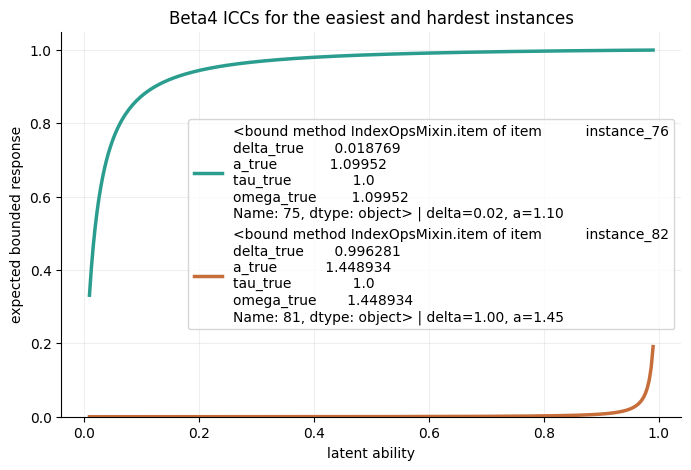

,item,delta_true,a_true,tau_true,omega_true


In [4]:
theta_grid = np.linspace(0.01, 0.99, 300)

easiest_item = item_params.nsmallest(1, 'delta_true').iloc[0]
hardest_item = item_params.nlargest(1, 'delta_true').iloc[0]

fig, ax = plt.subplots(figsize=(8, 5))
for row, color in [(easiest_item, '#2a9d8f'), (hardest_item, '#c76d3a')]:
    icc = beta4_expected_response(
        theta=theta_grid,
        difficulty=row.delta_true,
        discrimination_sign=row.tau_true,
        discrimination_magnitude=row.omega_true,
        discrimination=row.a_true,
    )
    ax.plot(
        theta_grid,
        icc,
        linewidth=2.5,
        color=color,
        label=(
            f"{row.item} | delta={row.delta_true:.2f}, a={row.a_true:.2f}"
        ),
    )

ax.set_title('Beta4 ICCs for the easiest and hardest instances')
ax.set_xlabel('latent ability')
ax.set_ylabel('expected bounded response')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.2)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.show()

display(item_params.loc[item_params['item'].isin([easiest_item.item, hardest_item.item])])


## Task 3: Train Beta4 on the synthetic `pij`

Fit Beta4 on the matrix you created.

Keep the original sampled parameters so you can compare them with the fitted estimates after training.


In [5]:
birt = Beta4(
    learning_rate=1,
    epochs=5000,
    n_respondents=pij.shape[0],
    n_items=pij.shape[1],
    n_inits=100,
    n_workers=1,
    random_seed=11,
    tol=10**(-8),
    set_priors=True,
)

birt.fit(pij.T.values)

model_recovery = model_params.copy()
model_recovery['theta_hat'] = birt.abilities

item_recovery = item_params.copy()
item_recovery['delta_hat'] = birt.difficulties
item_recovery['a_hat'] = birt.discriminations

display(model_recovery.head())
display(item_recovery.head())


  1%|          | 41/5000 [00:00<00:12, 408.25it/s]

  3%|▎         | 146/5000 [00:00<00:09, 492.86it/s]

  6%|▌         | 302/5000 [00:00<00:09, 511.72it/s]

  8%|▊         | 406/5000 [00:00<00:08, 512.78it/s]

 10%|█         | 511/5000 [00:01<00:08, 514.76it/s]

...

 95%|█████████▌| 4754/5000 [00:09<00:00, 521.23it/s]

 97%|█████████▋| 4860/5000 [00:09<00:00, 522.08it/s]

100%|██████████| 5000/5000 [00:09<00:00, 514.66it/s]


,model,theta_true,theta_hat
0,model_1,0.204779,0.322424
1,model_2,0.954475,0.859629
2,model_3,0.351761,0.420918
3,model_4,0.419128,0.463466
4,model_5,0.706541,0.627299


,item,delta_true,a_true,tau_true,omega_true,delta_hat,a_hat
0,instance_1,0.744319,1.610108,1.0,1.610108,0.660240,1.411434
1,instance_2,0.769049,1.339887,1.0,1.339887,0.679453,1.233910
2,instance_3,0.141439,0.871438,1.0,0.871438,0.272101,0.784095
3,instance_4,0.424410,1.627590,1.0,1.627590,0.465176,1.222975
4,instance_5,0.952618,1.262793,1.0,1.262793,0.874405,1.288769


## Task 4: Check whether recovery succeeded

Compare the original and estimated latent parameters.

At minimum, produce a recovery plot for ability:

- `theta_i` versus `theta_i_hat`

If possible, repeat the same logic for difficulty and discrimination as well.


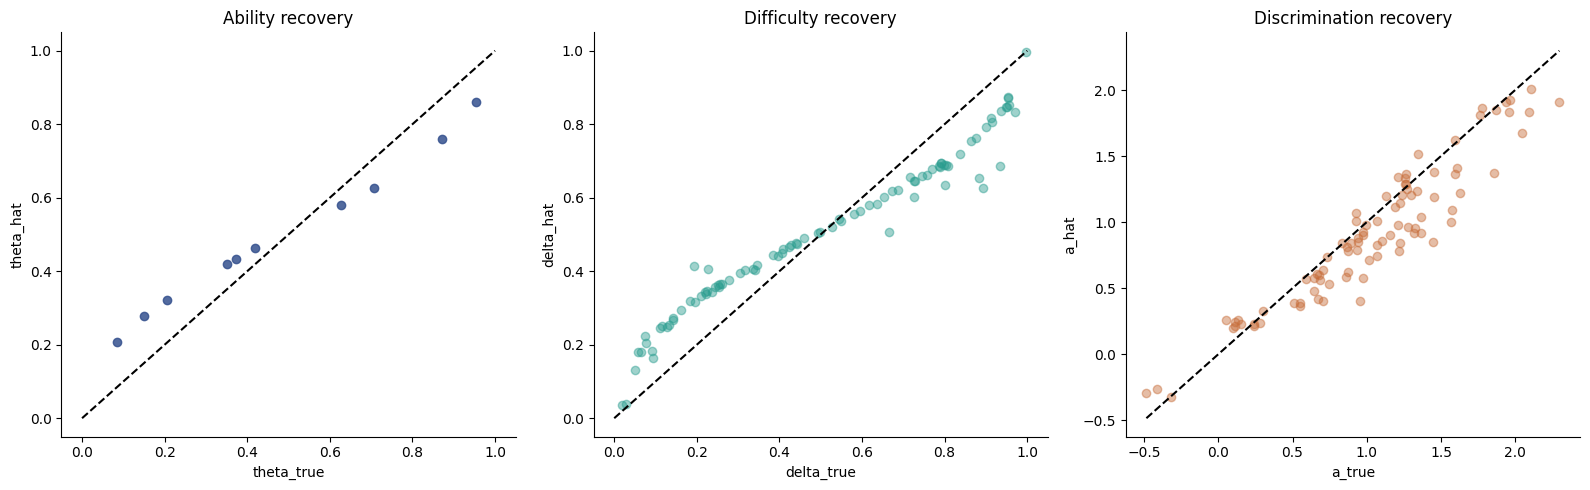

,parameter,correlation,mae
0,ability_theta,0.9960,0.0875
1,difficulty_delta,0.9756,0.0943
2,discrimination_a,0.9446,0.1724


In [6]:
recovery_summary = pd.DataFrame(
    {
        'parameter': ['ability_theta', 'difficulty_delta', 'discrimination_a'],
        'correlation': [
            np.corrcoef(model_recovery['theta_true'], model_recovery['theta_hat'])[0, 1],
            np.corrcoef(item_recovery['delta_true'], item_recovery['delta_hat'])[0, 1],
            np.corrcoef(item_recovery['a_true'], item_recovery['a_hat'])[0, 1],
        ],
        'mae': [
            np.mean(np.abs(model_recovery['theta_true'] - model_recovery['theta_hat'])),
            np.mean(np.abs(item_recovery['delta_true'] - item_recovery['delta_hat'])),
            np.mean(np.abs(item_recovery['a_true'] - item_recovery['a_hat'])),
        ],
    }
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(model_recovery['theta_true'], model_recovery['theta_hat'], alpha=0.85, color='#35518e')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='black')
axes[0].set_title('Ability recovery')
axes[0].set_xlabel('theta_true')
axes[0].set_ylabel('theta_hat')
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].scatter(item_recovery['delta_true'], item_recovery['delta_hat'], alpha=0.45, color='#2a9d8f')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='black')
axes[1].set_title('Difficulty recovery')
axes[1].set_xlabel('delta_true')
axes[1].set_ylabel('delta_hat')
axes[1].spines[['top', 'right']].set_visible(False)

min_a = float(min(item_recovery['a_true'].min(), item_recovery['a_hat'].min()))
max_a = float(max(item_recovery['a_true'].max(), item_recovery['a_hat'].max()))
axes[2].scatter(item_recovery['a_true'], item_recovery['a_hat'], alpha=0.45, color='#c76d3a')
axes[2].plot([min_a, max_a], [min_a, max_a], linestyle='--', color='black')
axes[2].set_title('Discrimination recovery')
axes[2].set_xlabel('a_true')
axes[2].set_ylabel('a_hat')
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

display(recovery_summary.round(4))


## Reflection Questions

1. Did the sampled parameter distributions produce a visibly diverse `pij` matrix?
2. How different were the ICCs of the easiest and hardest instances?
3. Was the recovery strongest for ability, difficulty, or discrimination?
4. Why is this synthetic recovery exercise a good preparation for the later CLAIRE section?
